<a href="https://colab.research.google.com/github/MeherunNessaEva/CodeAlpha_Web-Scrapping-Books/blob/main/codeAlpha_webScrap(Book).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install beautifulsoup4 requests pandas

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [7]:
base_url = "https://books.toscrape.com"
response = requests.get(base_url)

print(response.status_code)

200


In [5]:
print(response.text[:1000])

<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->
    <head>
        <title>
    All products | Books to Scrape - Sandbox
</title>

        <meta http-equiv="content-type" content="text/html; charset=UTF-8" />
        <meta name="created" content="24th Jun 2016 09:29" />
        <meta name="description" content="" />
        <meta name="viewport" content="width=device-width" />
        <meta name="robots" content="NOARCHIVE,NOCACHE" />

        <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
        <!--[if lt IE 9]>
        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>
        <![endif]-->

        
            <link rel="shortcut icon" href="static/oscar/favicon.

In [4]:
soup = BeautifulSoup(response.text, 'html.parser')

In [6]:
all_books = []

In [9]:
for page in range(1, 6):

    url = base_url.format(page)

    print(f"Scraping Page {page}...")

    response = requests.get(url)

    soup = BeautifulSoup(response.text, 'html.parser')

    books = soup.find_all('article', class_='product_pod')

    for book in books:

        title = book.h3.a['title']

        price = book.find('p', class_='price_color').text

        availability = book.find('p', class_='instock availability').text.strip()

        rating = book.p['class'][1]

        all_books.append({
            'Title': title,
            'Price': price,
            'Availability': availability,
            'Rating': rating
        })

Scraping Page 1...
Scraping Page 2...
Scraping Page 3...
Scraping Page 4...
Scraping Page 5...


In [10]:
df = pd.DataFrame(all_books)

In [11]:
df.head(10)

,Title,Price,Availability,Rating
0,A Light in the Attic,Â£51.77,In stock,Three
1,Tipping the Velvet,Â£53.74,In stock,One
2,Soumission,Â£50.10,In stock,One
3,Sharp Objects,Â£47.82,In stock,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,In stock,Five
5,The Requiem Red,Â£22.65,In stock,One
6,The Dirty Little Secrets of Getting Your Dream...,Â£33.34,In stock,Four
7,The Coming Woman: A Novel Based on the Life of...,Â£17.93,In stock,Three
8,The Boys in the Boat: Nine Americans and Their...,Â£22.60,In stock,Four
9,The Black Maria,Â£52.15,In stock,One


In [12]:
df.shape

(200, 4)

In [13]:
df.to_csv('books_data.csv', index=False)

print("CSV File Saved Successfully!")

CSV File Saved Successfully!


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

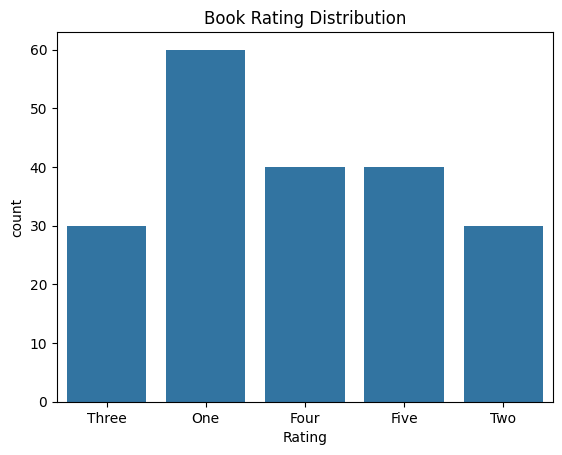

In [15]:
sns.countplot(x='Rating', data=df)

plt.title('Book Rating Distribution')

plt.show()

In [16]:
df['Availability'].value_counts()

,count
Availability,
In stock,200


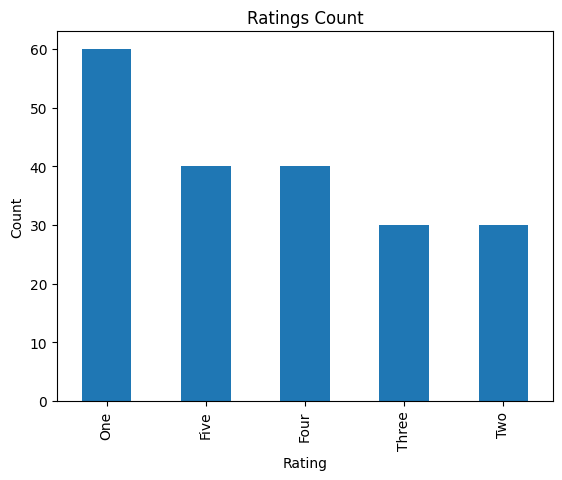

In [17]:
df['Rating'].value_counts().plot(kind='bar')

plt.title('Ratings Count')

plt.xlabel('Rating')

plt.ylabel('Count')

plt.show()